# TP sur le pont de fremont

### Appel des bibliothèques

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests

### On va chercher le fichier dans notre dossier

In [66]:

local_file = "data/fremont.csv"
URL = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"


if Path(local_file).exists():
    print(f"le fichier {local_file} est déjà là")
else:
    print(f"allons chercher le fichier {local_file}")

    req = requests.get(URL)
    print(req.status_code)

    with open(local_file, 'w') as writer:
        writer.write(req.text)


le fichier data/fremont.csv est déjà là


#### On lit le fichier

In [67]:
data = pd.read_csv(local_file)
data.shape

(175200, 4)

In [68]:
data.head()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


#### On supprime les doublons :

data est sous forme de DataFrame donc on peut l'appeler directement pour le drop.
Pour faire ça en place, on rajoute la variable 'inplace'

In [69]:
data.drop_duplicates('Date', keep = 'last', inplace = True)
data.shape

(87600, 4)

## Echauffement

In [70]:
sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])


1. Sample_dates est de type DatetimeIndex

2.  - sample_dates.date renvoie un array constitué des lignes de la colonne Date du tableau
- sample_dates.time renvoie un array qui correspond aux différentes heures indiquées dans le tableau
- sample_dates.dayofweek renvoie une liste de taille de l'index renseignant le jour de l semaine associé dans une liste de la taille de l'index (0 pour lunid, 6 pour dimanche)


In [71]:
#sample_dates.date

#sample_dates.time

#sample_dates.dayofweek

3. 
On compare les lignes du DatetimeIndex avec le string de date (un peu boîte noire)

In [72]:
sample_dates[sample_dates >= '2024-01-20' ]

DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)

4.  - On utilise l'intersection de date pour encadrer le mois de Janvier 

In [73]:
sample_dates[ ('2024-01-01' <= sample_dates) & (sample_dates <='2024-01-31') ]

DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)

### Parser les dates

In [74]:
data.info()
data.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 87600 to 175199
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 2.7 MB


Date                                str
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

In [75]:
data.index = pd.to_datetime(data.Date, format = '%m/%d/%Y %I:%M:%S %p')
del data["Date"]

- On réattribue d'abord l'indice en mettant la date, puis on supprime le doublon qui n'est pas du bon type
- On fait cela pour pouvoir repérer les évènements avec leur date, puisqu'il n'y a pas deux évènements différents à la même date

In [76]:
data.head()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


### Renommer les colonnes

In [77]:
data.columns = ['Total', 'West', 'East']

### Données manquantes

1. On affiche les lignes incomplètes :

In [80]:
print('Le nombre de lignes avec un élément manquant est :')
data[data.isna().any(axis=1)].shape[0]

Le nombre de lignes avec un élément manquant est :


14

2. 
La méthode DataFrame 

In [82]:
data = data.convert_dtypes(convert_integer = True)

### Affichage

<Axes: xlabel='Date'>

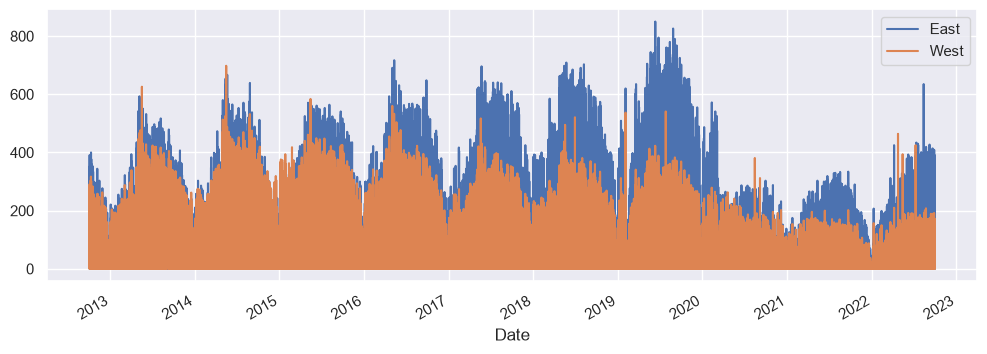

In [83]:
sns.set(rc={'figure.figsize': (12, 4)})
data[['East', 'West']].plot()

## Changer la fréquence temporelle

1. Nombre de passage agrégé, par semaine :

Pour l'affichage, la fonction resample permet de changer notre 'fréquence d'échantillonage' des données

<Axes: title={'center': 'Nombre de passages par semaine'}, xlabel='Date'>

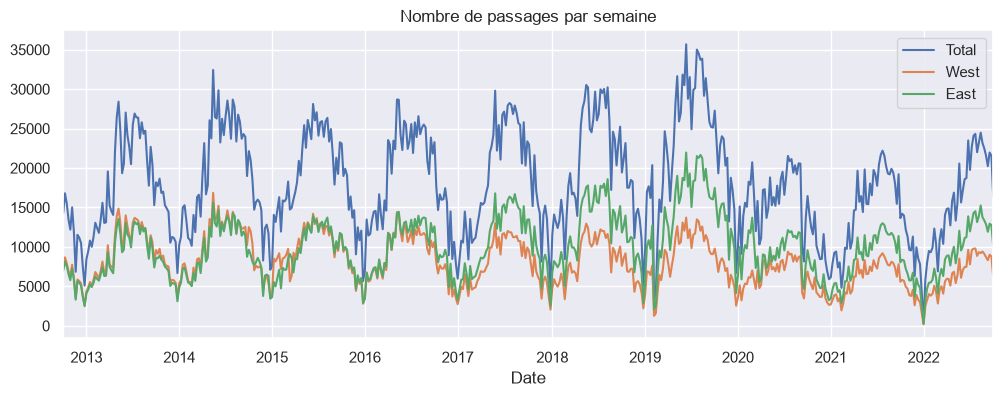

In [86]:
data.resample("1W").sum().plot(
    figsize = (12,4),
    title = "Nombre de passages par semaine"
)


2. Vérification de la taille

In [89]:
if data.shape[0] <= data.resample("1W").sum().shape[0]*7*24 :
    print("Hourra")
else :
    print("Non") 

Hourra


### Découpage temporel

In [91]:
data = data[ data.index <= '2017-12-31']

On utilise la même logique que précédemment pour la selection dans le dataframe

### Evolution annuelle

In [ ]:
data.resample("1d").sum().rolling(365).sum() 
plt.plot()

/var/folders/10/k6m3t7c57g71r9cpgdl97d_m0000gn/T/ipykernel_35831/1608190388.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  data.resample("1d").sum().rolling(365).sum()


,Total,West,East
Date,,,
2012-10-03,NaN,NaN,NaN
2012-10-04,NaN,NaN,NaN
2012-10-05,NaN,NaN,NaN
2012-10-06,NaN,NaN,NaN
2012-10-07,NaN,NaN,NaN
...,...,...,...
2017-12-27,964282.0,412992.0,551290.0
2017-12-28,963782.0,412759.0,551023.0
2017-12-29,963239.0,412505.0,550734.0
